 Project Scenario

"Customer churn has increased over the past few months. We have customer data, but we don't know who is likely to leave. Build a machine learning solution that predicts churn so our marketing team can contact at-risk customers before they leave."Develop a machine learning model that predicts customer churn using historical customer data and provides business recommendations to improve customer retention.

In [2]:
pip install pandas, numpy matplotlib seaborn scikit-learn xgboost shap streamlit imbalanced-learn joblib

Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: 'pandas,'

[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Data Collection

import libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

# Display plots inside Jupyter Notebook
%matplotlib inline

In [5]:
df = pd.read_csv("dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Display First Five Rows

df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# Display Dataset Shape
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 7043
Columns: 21


In [7]:
# Step 2: Display Last 5 Rows
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [8]:
#display colum names
df.columns


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [9]:
#check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
#Statistical Summary (to get mean, median, std,count)
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [11]:
#Categorical Summary
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [12]:
#missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
# Check blank values in TotalCharges
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [14]:
#Check Duplicate Records
df.duplicated()


0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Length: 7043, dtype: bool

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
#Check Unique Values in Each Column
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [17]:
#Target Variable Distribution
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [18]:
(df["Churn"].value_counts(normalize=True) * 100).round(2)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

5,174 customers stayed with the company (No).
1,869 customers left the company (Yes).

Out of every 100 customers:

About 73 customers stayed.
About 27 customers left.

Data Cleaning

In [19]:
 #Check Blank Values
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [20]:
#Replace Blank Values with NaN

df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

In [21]:
#chechking blank spaces are exit
(df["TotalCharges"] == " ").sum()

np.int64(0)

In [22]:
#Convert Data Type into numeric the total charges colum

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [23]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [24]:
#(removig the missing values because Removing them has almost no effect on the dataset.It avoids introducing artificial values. )
#Remove Missing Values 
df.dropna(inplace=True)
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [27]:
print(df.shape)   #orginally there is 7043 rows there we remove 11 misig values from data now it is 7032

(7032, 21)


Exploratory Data Analysis (EDA)

In [28]:
#  Identify Numerical and Categorical Columns

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include=['object']).columns


print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

Categorical Columns:
Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')


Observation: The majority of customers are not senior citizens (0), while a smaller proportion are senior citizens (1).

1.  Churn Distribution

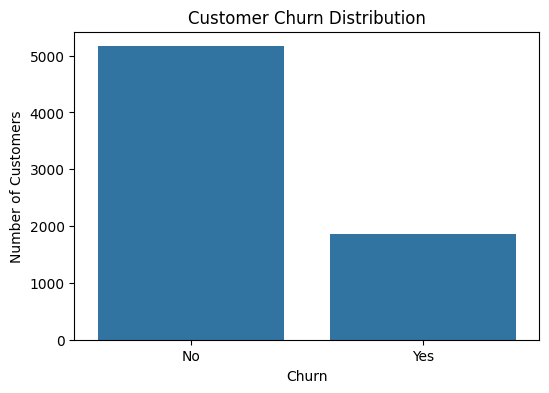

In [29]:
#Churn Distribution

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

Observation:

Most customers did not churn.
Around 73.46% of customers stayed with the company.
Around 26.54% of customers churned.
The dataset is moderately imbalanced because the number of customers who stayed is much higher than those who churned.

2. Contract Type vs Churn

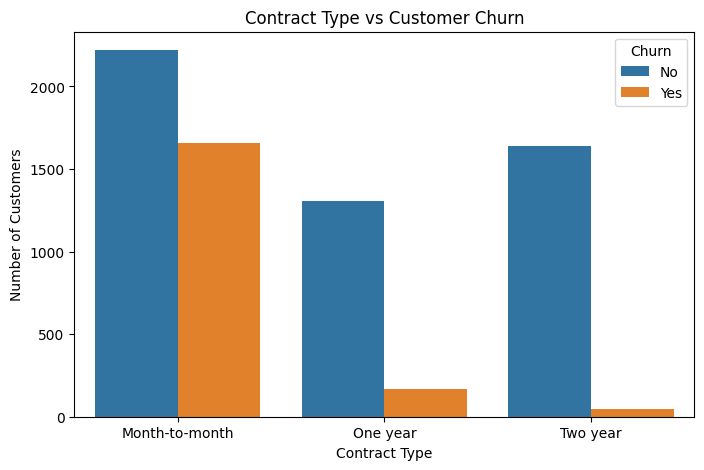

In [30]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

Observation:

Customers with Month-to-month contracts have the highest churn.
Customers with One-year and Two-year contracts have much lower churn.
Longer-term contracts appear to improve customer retention.

Customers on month-to-month contracts are more likely to leave because they are not committed for a long period. Encouraging these customers to switch to annual or two-year contracts could help reduce churn.

3. Internet Service vs Churn

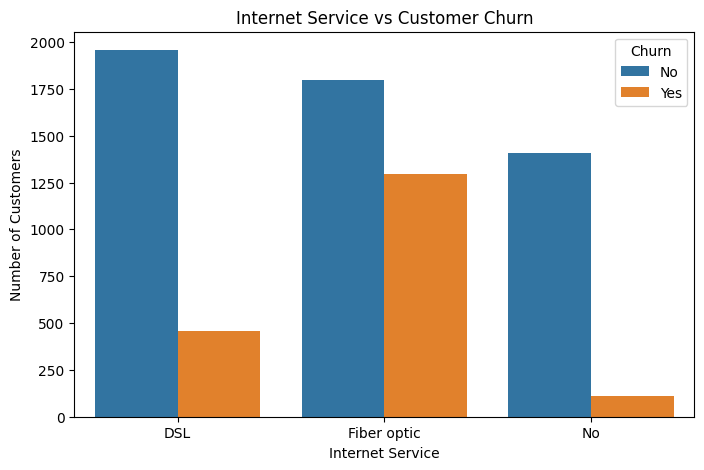

In [31]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="InternetService", hue="Churn")

plt.title("Internet Service vs Customer Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

Observation

From the graph, we can observe:

Fiber optic customers have the highest number of churned customers.
DSL customers have a much lower number of churned customers.
Customers with No Internet Service have the lowest churn.
Although many Fiber optic customers stay, the number of customers leaving is much higher than in the other internet service categories.

4. Tech Support vs Churn

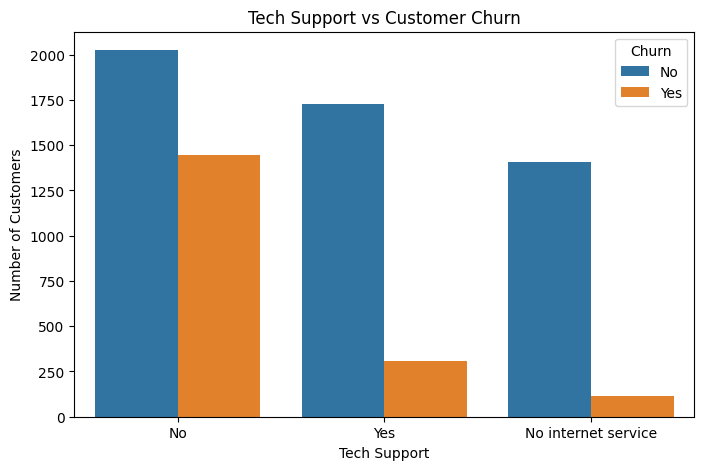

In [32]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="TechSupport", hue="Churn")

plt.title("Tech Support vs Customer Churn")
plt.xlabel("Tech Support")
plt.ylabel("Number of Customers")

plt.show()

Observation

From the graph, we can observe:

Customers without Tech Support ("No") have the highest number of churned customers.
Customers with Tech Support ("Yes") have much lower churn.
Customers with No Internet Service also have very low churn, but they don't use internet-based services, so tech support is less relevant for them.

5. Monthly Charges Distribution

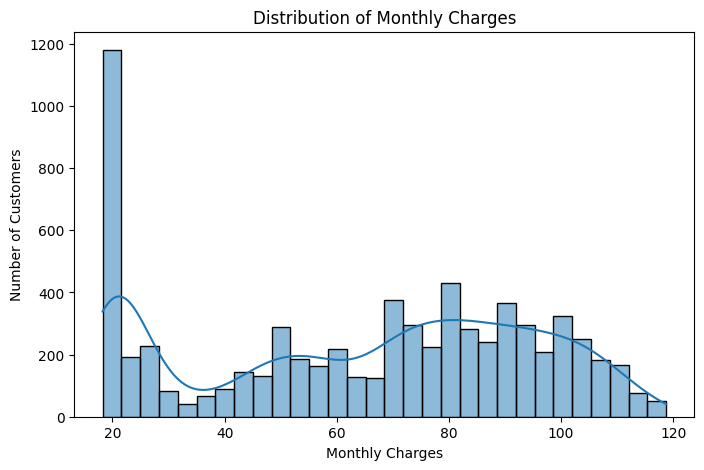

In [33]:
plt.figure(figsize=(8,5))

sns.histplot(df["MonthlyCharges"], bins=30, kde=True)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

Observation

From the graph, we can observe:

Monthly charges range from approximately ₹18 to ₹120.
A large number of customers pay around ₹20 per month.
Another large group of customers pays between ₹70 and ₹100 per month.
The distribution is not normally distributed. It has multiple peaks (multimodal) instead of one single peak.

6. Tenure Distribution

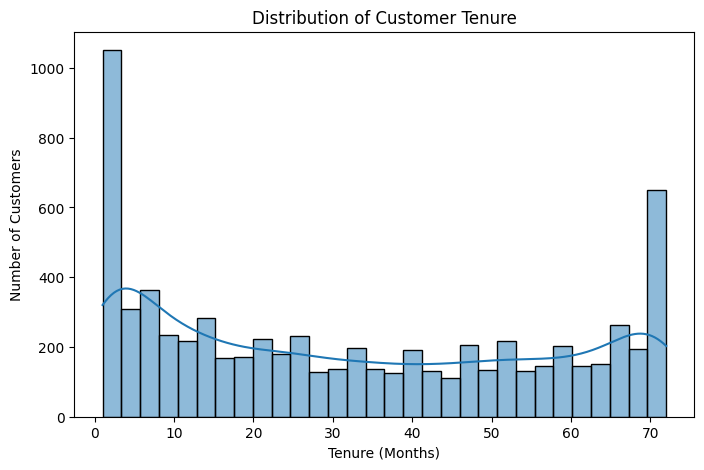

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(df["tenure"], bins=30, kde=True)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

Observation

From the graph, we can observe:

Customer tenure ranges from 1 month to 72 months.
A large number of customers have a very short tenure (1–5 months).
Another large group of customers has a very long tenure (around 70–72 months).
There are fewer customers in the middle tenure range.
The distribution is bimodal (two peaks), not normally distributed.

7. Monthly Charges vs Churn

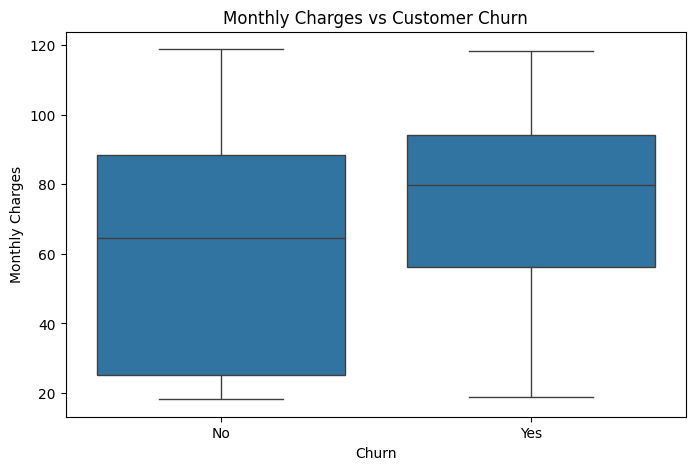

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()


Observation

From your graph, we can observe:

Customers who did not churn (No) have a median monthly charge of approximately ₹64.
Customers who churned (Yes) have a higher median monthly charge of approximately ₹80.
The monthly charges for churned customers are generally higher than those of customers who stayed.
Both groups have similar minimum and maximum values, but the overall distribution for churned customers is shifted toward higher charges.

8.  Tenure vs Churn

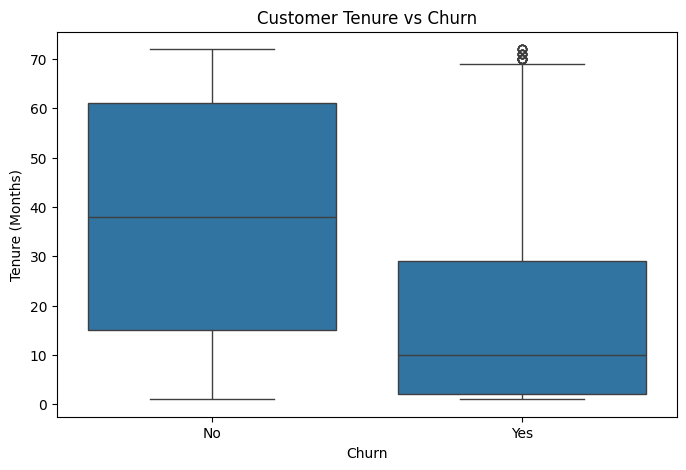

In [38]:

plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Churn", y="tenure")

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

Observation

From your graph, we can observe:

Customers who did not churn (No) have a much higher median tenure (around 38 months).
Customers who churned (Yes) have a much lower median tenure (around 10 months).
Most churned customers have been with the company for only a short period.
Most long-term customers remain with the company.
A few churned customers with very high tenure (around 70–72 months) appear as outliers.

8. Correlation Heatmap

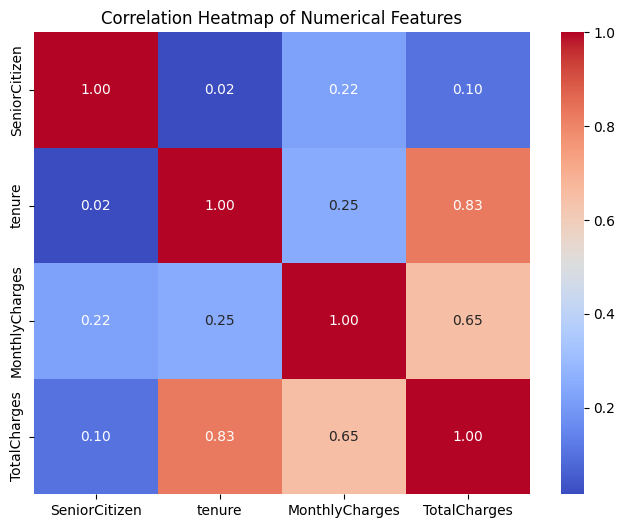

In [39]:

plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

Observation of the Correlation Heatmap
Tenure and TotalCharges have a strong positive correlation (0.83). This means customers who stay with the company for a longer time tend to have higher total charges because they continue paying for the service over many months.
MonthlyCharges and TotalCharges have a moderate positive correlation (0.65). Customers with higher monthly bills generally accumulate higher total charges over time.
Tenure and MonthlyCharges have a weak positive correlation (0.25). This indicates that the length of time a customer stays with the company has only a small relationship with their monthly bill.

SeniorCitizen has very weak correlations with the other numerical features:

SeniorCitizen ↔ Tenure = 0.02
SeniorCitizen ↔ MonthlyCharges = 0.22
SeniorCitizen ↔ TotalCharges = 0.10

This suggests that being a senior citizen has little influence on these numerical variables.

# Data Preprocessing

In [47]:
#REMOVE CUTOMER ID COLUM
df = df.drop("customerID", axis=1)



KeyError: "['customerID'] not found in axis"

In [48]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Separate Features and Target

In [59]:
# Separate Features and Target

X=df.drop("Churn", axis=1)
print(X.head())


   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1              Yes          No  

In [60]:
y = df["Churn"]
print(y.head())

0     No
1     No
2    Yes
3     No
4    Yes
Name: Churn, dtype: object


In [61]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (7032, 19)
Shape of y: (7032,)


Encode Categorical Variables

In [63]:
# One-Hot Encode Categorical Features
X = pd.get_dummies(X, drop_first=True)

print(X.shape)
print(X.head())

(7032, 30)
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85        False   
1              0      34           56.95       1889.50         True   
2              0       2           53.85        108.15         True   
3              0      45           42.30       1840.75         True   
4              0       2           70.70        151.65        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  MultipleLines_Yes  ...  \
0                            True              False  ...   
1                           False              False  ...   
2                           False              False  ...   
3    

In [64]:
# Convert True/False to 1/0

X = X.astype(int)

print(X.head())

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1              29            29            0   
1              0      34              56          1889            1   
2              0       2              53           108            1   
3              0      45              42          1840            1   
4              0       2              70           151            0   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0            1               0                 0   
1            0               0                 1   
2            0               0                 1   
3            0               0                 0   
4            0               0                 1   

   MultipleLines_No phone service  MultipleLines_Yes  ...  \
0                               1                  0  ...   
1                               0                  0  ...   
2                               0                  0  ...   
3               

# Train-Test Split

In [71]:
pip install scikit-learn

  Using cached scikit_learn-1.9.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.24.0-py3-none-any.whl.metadata (15 kB)
Using cached scikit_learn-1.9.0-cp312-cp312-win_amd64.whl (8.2 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached narwhals-2.24.0-py3-none-any.whl (461 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [73]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (5625, 30)
X_test shape : (1407, 30)
y_train shape: (5625,)
y_test shape : (1407,)


# Feature Scaling

In [75]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Numerical columns to scale
numerical_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

# Scale training data
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])

# Scale testing data
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [76]:
print(X_train.head())

      SeniorCitizen    tenure  MonthlyCharges  TotalCharges  gender_Male  \
1413              0  1.321816        0.978740      1.659778            1   
7003              0 -0.267410       -0.980943     -0.562267            1   
3355              0  1.444064        0.845881      1.756025            0   
4494              0 -1.204646        0.646591     -0.908142            1   
3541              0  0.669826       -0.814868     -0.101685            0   

      Partner_Yes  Dependents_Yes  PhoneService_Yes  \
1413            1               1                 1   
7003            0               0                 0   
3355            1               0                 1   
4494            0               0                 1   
3541            1               0                 0   

      MultipleLines_No phone service  MultipleLines_Yes  ...  \
1413                               0                  1  ...   
7003                               1                  0  ...   
3355                

# Machine Learning Model Building

In [ ]:
#Check Class Imbalance

#No → 5174 customers (73.46%)
#Yes → 1869 customers (26.54%)
#The model will see many more "No" examples than "Yes" examples.
#We need to understand whether this imbalance is severe enough to require techniques like SMOTE or class_weight.

In [77]:
# Check Class Imbalance
print("Target Class Distribution:")
print(y.value_counts())

print("\nPercentage Distribution:")
print((y.value_counts(normalize=True) * 100).round(2))

Target Class Distribution:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Percentage Distribution:
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


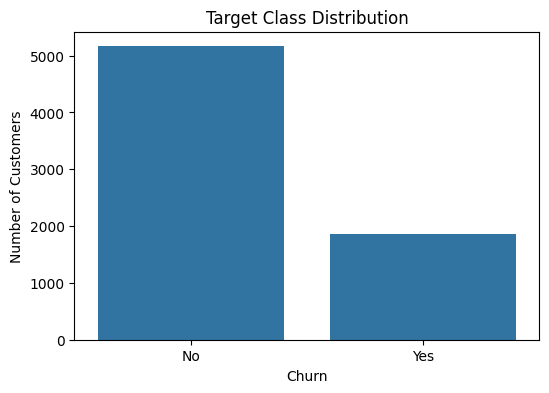

In [78]:
# Visualize Target Class Distribution
plt.figure(figsize=(6,4))

sns.countplot(x=y)

plt.title("Target Class Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

Observation

The target variable is moderately imbalanced.

73.42% of customers did not churn, while 26.58% of customers churned.
Although the dataset is not perfectly balanced, the imbalance is not severe.
We will first train baseline machine learning models on the original data and later evaluate whether class balancing techniques such as class weights or SMOTE are needed.